In [1]:
import pandas as pd
import numpy as np
import os
import mo_gymnasium as mo_gym
import gymnasium as gym
from env.user_sim import UserSimEnv
import env.simulate as sim_utils
from morl_baselines.multi_policy.morld import morld
from morl_baselines.common.pareto import ParetoArchive, get_non_pareto_dominated_inds
from morl_baselines.common.weights import equally_spaced_weights, random_weights
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from ipywidgets import interact
import value_iteration
import utils
from morld.vi_morld_simple import VIMORLD
from morld.mo_pi import MOPolicyIteration
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.indicators.hv import HV
from pymoo.operators.survival.rank_and_crowding.metrics import get_crowding_function
import math
from moocore import hypervolume, hv_contributions
from morl_baselines.common.utils import nearest_neighbors
import mdp_utils

seed = 42
np.random.seed(seed)

In [2]:
MAX_COUNT = 2
NUM_FEATURES = 3
NUM_VALS = 3
NUM_USER_STATES = NUM_VALS**NUM_FEATURES
NUM_CLUSTERS = 6
NUM_COUNT_STATES = (MAX_COUNT+1)**NUM_CLUSTERS
NUM_STATES = NUM_USER_STATES * NUM_COUNT_STATES 
NUM_ACTIONS = NUM_CLUSTERS
NUM_OBJECTIVES = 5

In [3]:
data_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\data\\functions\\3'
results_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\results\\'

action_data = pd.read_csv(os.path.join(data_folder, 'action_data.csv'))
df = pd.read_csv(os.path.join(data_folder, 'samples.csv'))
cluster_col = 'cluster_all'

actions_clustered, _, cluster_cols = utils.cluster_actions(action_data, cluster_vars=['obs_diff', 'obs_time', 'obs_liked', 'obs_pu'], num_clusters=NUM_CLUSTERS)

action_categories = actions_clustered[cluster_col].values

reward_cols = ["obs_time", "obs_liked", "obs_pu", "r_expert", "r_diversity"]

obj_clusters = {r_col: cluster_col for r_col in reward_cols}
nO = len(obj_clusters)
P_c_clustered = mdp_utils.compute_completion_probabilities_clustered(df, cluster_col, NUM_USER_STATES, NUM_ACTIONS, num_clusters=NUM_CLUSTERS, use_clusters=True)
R_clustered = mdp_utils.compute_rewards_clustered(df, 
                                          P_c_clustered, 
                                          obj_clusters, 
                                          NUM_USER_STATES, 
                                          NUM_COUNT_STATES, 
                                          NUM_ACTIONS, 
                                          nO, 
                                          action_categories,
                                          num_clusters=NUM_CLUSTERS,
                                          count_cluster=cluster_col,
                                          use_clusters=True)
P_clustered = mdp_utils.compute_transition_probabilities_clustered(df, 
                                                                    NUM_USER_STATES, 
                                                                    NUM_ACTIONS, 
                                                                    cluster_col, 
                                                                    num_clusters=NUM_CLUSTERS, 
                                                                    use_clusters=True)

print("P shape:", P_clustered.shape)  # Should be (nU, nA, nU)
print("R shape:", R_clustered.shape)  # Should be (nU, nC, nA, nO)

P shape: (27, 6, 27)
R shape: (27, 729, 6, 5)


In [4]:
challenges_per_cluster = [[i for i in range(len(actions_clustered)) if actions_clustered[cluster_col].iloc[i] == cluster_id] for cluster_id in range(NUM_CLUSTERS)]
print("Challenges per cluster:", challenges_per_cluster)
challenge_info = actions_clustered.set_index('action_id').to_dict('records')
print("Challenge info example:", challenge_info[0])

Challenges per cluster: [[3, 6, 13, 14, 15, 18, 21, 27, 38, 41, 43, 46, 55, 58, 61, 63, 65, 67, 69, 80, 90, 94, 97], [16, 17, 42, 45, 51, 75, 84, 98, 102], [4, 9, 12, 22, 31, 32, 33, 34, 35, 53, 76, 79, 88, 89], [2, 10, 19, 24, 39, 40, 48, 49, 54, 56, 60, 66, 68, 73, 77, 83, 85, 86, 87, 91, 93, 100, 101, 103], [0, 1, 5, 7, 8, 26, 28, 37, 44, 47, 50, 52, 57, 62, 64, 71, 72, 78, 81, 96], [11, 20, 23, 25, 29, 30, 36, 59, 70, 74, 82, 92, 95, 99]]
Challenge info example: {'obs_diff': 0.2857142857142857, 'obs_time': 0.2733990147783251, 'obs_liked': 0.8128078817733989, 'obs_pu': 0.9359605911330048, 'category_id': 0, 'obs_diff_cluster': 5, 'obs_time_cluster': 1, 'obs_liked_cluster': 2, 'obs_pu_cluster': 2, 'cluster_all': 4}


In [6]:
env = mo_gym.make('user_env', num_actions=NUM_CLUSTERS, 
                 num_objectives = NUM_OBJECTIVES, 
                 challenge_info=challenge_info, 
                 challenges_per_cluster=challenges_per_cluster,
                 num_clusters=NUM_CLUSTERS,
                 transition_probs=P_clustered, 
                 completion_probs=P_c_clustered,
                 reward_matrix=R_clustered, 
                 action_categories=np.array([i for i in range(NUM_CLUSTERS)]),
                 MAX_COUNT=MAX_COUNT)

In [7]:
num_evals = 30
pop_size = 16
num_iters = 2
num_steps_per_episode=28
total_steps = 50
weights_init = "combined"
scalarization = "linear"
max_archive_size = 20

model_name = f'pimorld_T={total_steps}_P={pop_size}_nO={NUM_OBJECTIVES}_{scalarization}_{weights_init}'
filename = model_name
model_file = os.path.join(results_folder, model_name, 'weights', filename)

In [10]:
seed = 42
random_state = np.random.default_rng(seed)

# rewards: objectives = ["Time Required", "Fun", "Perceived Usefulness", "Expert Usefulness", "Diversity", "Completion Rate"]
gammas = np.array([0.5, 0.2, 0.7, 0.7, 0.7, 0.2])  # Discount factors for each objective
gamma = 0.7
ref_point = np.array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5])  # Reference point for Chebyshev scalarization

def add_to_pareto_archive(agent, pareto_archive):
    for ind in pareto_archive.individuals:
        if np.array_equal(ind['policy'], agent.policy_table):
            print("Policy already in archive, skipping addition.")
            return
    individual = {
        'weights': agent.weights.copy(),
        'policy': agent.policy_table.copy(),
        'V': agent.V_full.copy()
    }
    pareto_archive.add(individual, agent.expected_return)

def adapt_weights_random(agents, pareto_archive, num_iterations=2):
    for i in range(num_iterations):
        print("Weight adaptation cycle: ", i+1)
        for agent in agents:
            # add some random noise to the weights, ensure positivity and normalization
            noise = random_state.normal(1, 0.1, size=agent.weights.shape)
            new_weights = agent.weights * noise
            # normalize the weights
            new_weights /= np.sum(new_weights)
            agent.set_weights(new_weights)
            add_to_pareto_archive(agent, pareto_archive)

def intialize_agents(env, pop_size, gamma, max_eval_iters=500, scalarization='linear', ref_point=None, weights_init='uniform', random_state=None):
    agents = []
    pareto_archive = ParetoArchive()
    if weights_init == 'random':
        all_weights = random_weights(NUM_OBJECTIVES, pop_size, rng=random_state)
    elif weights_init == 'uniform':
        all_weights = get_reference_directions("energy", NUM_OBJECTIVES, pop_size, seed=1)
    elif weights_init == 'combined':
        uniform_weights = get_reference_directions("energy", NUM_OBJECTIVES, pop_size//2, seed=1)
        random_weights_arr = random_weights(NUM_OBJECTIVES, pop_size//2, rng=random_state)
        all_weights = np.vstack((uniform_weights, random_weights_arr))
    print("Initial weights for agents:")
    print(all_weights)

    for i in range(pop_size):
        weigths = all_weights[i]
        vi_agent = MOPolicyIteration(id=i, env=env.unwrapped, weights=weigths, gamma=gamma, ref_point=ref_point, scalarization=scalarization)
        vi_agent.train(max_eval_iters=max_eval_iters)
        vi_agent.evaluate()
        agents.append(vi_agent)
        add_to_pareto_archive(vi_agent, pareto_archive)
    return agents, pareto_archive

population, pareto_archive = intialize_agents(env, pop_size, gamma, scalarization=scalarization, ref_point=ref_point, weights_init='combined')
# adapt_weights_random(population, pareto_archive, num_iterations=num_iters)


Initial weights for agents:
[[0.         0.         0.         0.         1.        ]
 [0.         0.         0.         1.         0.        ]
 [0.         0.         0.49799681 0.         0.50200319]
 [0.         0.         1.         0.         0.        ]
 [0.         1.         0.         0.         0.        ]
 [0.30391237 0.         0.30386081 0.39222682 0.        ]
 [0.4969631  0.5030369  0.         0.         0.        ]
 [1.         0.         0.         0.         0.        ]
 [0.28719498 0.13023474 0.3275255  0.25171829 0.00332648]
 [0.24920702 0.06411612 0.24549155 0.30105863 0.14012668]
 [0.13232872 0.34975425 0.02256447 0.36773017 0.12762239]
 [0.56797976 0.29066775 0.00723784 0.03496936 0.09914529]
 [0.12871509 0.09278202 0.00995096 0.41017571 0.35837623]
 [0.2610148  0.00923211 0.07667572 0.58206061 0.07101676]
 [0.21477756 0.08861858 0.04774999 0.37907823 0.26977563]
 [0.24994625 0.08841985 0.47824556 0.17674555 0.0066428 ]]
Running policy iteration with weights: [0. 

In [11]:
def closest_non_dominated(eval_policy: np.ndarray, pareto_archive: ParetoArchive):
    """Returns the closest policy to eval_policy currently in the Pareto Archive.

    Args:
        eval_policy: evaluation where we want to find the closest one
        pareto_archive: the Pareto archive to search in
    Return:
        closest individual and evaluation in the pareto archive
    """
    closest_distance = math.inf
    closest_nd = None
    closest_eval = None
    for eval_candidate, candidate in zip(pareto_archive.evaluations, pareto_archive.individuals):
        distance = np.sum(np.square(eval_policy - eval_candidate))
        if closest_distance > distance > 0.01:
            closest_distance = distance
            closest_nd = candidate
            closest_eval = eval_candidate
    return closest_nd, closest_eval

def adapt_weights_psa(agents, pareto_archive, delta=0.2):   
    # P. Czyzżak and A. Jaszkiewicz,
    # "Pareto simulated annealing—a metaheuristic technique for multiple-objective combinatorial optimization,"
    # Journal of Multi-Criteria Decision Analysis, vol. 7, no. 1, pp. 34–47, 1998,
    # doi: 10.1002/(SICI)1099-1360(199801)7:1<34::AID-MCDA161>3.0.CO;2-6.
    for i, agent in enumerate(agents):
        eval_policy = agent.expected_return
        closest_nd, closest_eval = closest_non_dominated(eval_policy, pareto_archive)
        new_weights = agent.weights.copy()
        if closest_eval is not None:
            for i in range(len(eval_policy)):
                # Increases on the weights which are better than closest_eval, decreases on the others
                if eval_policy[i] >= closest_eval[i]:
                    new_weights[i] = agent.weights[i] * (1 + delta)
                else:
                    new_weights[i] = agent.weights[i] / (1 + delta)
        # Renormalizes so that the weights sum to 1.
        normalized = np.array(new_weights) / np.linalg.norm(np.array(new_weights), ord=1)
        print(f"Old weights: {agent.weights}, new weights: {normalized}")
        agent.set_weights(normalized)
        add_to_pareto_archive(agent, pareto_archive)

def agent_from_archive(individual, ind_eval, env, gamma, ref_point):
    agent = MOPolicyIteration(id=0, env=env.unwrapped, weights=individual['weights'], gamma=gamma, ref_point=ref_point)
    agent.policy_table = individual['policy'].copy()
    agent.V_full = individual['V'].copy()
    agent.expected_return = ind_eval.copy()
    return agent

# we want to generate a new population of agents, of pop_size
# which agents to select?
def generate_new_population(num_new_agents, population, pareto_archive, env, gamma, ref_point, max_eval_iters=5, scalarization='linear'):
    new_population = []
    new_weights = random_weights(NUM_OBJECTIVES, num_new_agents, rng=random_state)

    # for each new agent, we intialize it with new weights but the value function from the closest in weights from the population
    dist_metric = lambda a, b: np.sum(np.square(a - b))
    closest = [nearest_neighbors(1, w, [agent.weights for agent in population], dist_metric) for w in new_weights]
    print(closest)

    for i in range(num_new_agents):
        weigths = new_weights[i]
        V_init = population[closest[i][0]].V_full.copy()
        vi_agent = MOPolicyIteration(id=i, env=env.unwrapped, weights=weigths, V_init=V_init, gamma=gamma, ref_point=ref_point, scalarization=scalarization)
        vi_agent.train(max_eval_iters=max_eval_iters)
        new_population.append(vi_agent)
        add_to_pareto_archive(vi_agent, pareto_archive)
    return new_population

def select_parents(population, pareto_archive, num_parents):
    # Select parents based on pareto dominance and hypervolume contribution
    ref_point_HV = np.zeros(NUM_OBJECTIVES)   # Set reference point for hypervolume calculation TODO: adapt this to minimum values of the objectives in the population (or PA)
    non_dominated_inds = get_non_pareto_dominated_inds(np.array([agent.expected_return for agent in population]))
    parents = np.array(population)[non_dominated_inds]
    hv_cont = hv_contributions([agent.expected_return for agent in parents], ref_point_HV, maximise=True)
    sorted_inds = np.argsort(hv_cont)[::-1]
    parents = parents[sorted_inds]  # Reorder parents based on hypervolume contribution
    if len(parents) > num_parents:
        parents = parents[:num_parents]  # Select top num_parents based on hypervolume contribution
    return parents

print("Pareto archive size after initialization: ", len(pareto_archive.individuals))

# Evolve the population for a number of iterations 
num_iterations = 10
for i in range(num_iterations):
    old_pareto_size = len(pareto_archive.individuals)
    parents = select_parents(population, pareto_archive, num_parents=pop_size//2)
    offspring = list(parents.copy())
    adapt_weights_psa(offspring, pareto_archive, delta=0.2)
    print(f"After weight adaptation, Pareto archive size: {len(pareto_archive.individuals)}")
    population = list(np.concatenate([parents, offspring]))    


    
        

Pareto archive size after initialization:  15
Old weights: [0. 1. 0. 0. 0.], new weights: [0. 1. 0. 0. 0.]
Running policy iteration with weights: [0. 1. 0. 0. 0.]
Policy converged after 1 iterations.
Updated weights to [0. 1. 0. 0. 0.], re-computed policy.
Policy already in archive, skipping addition.
Old weights: [0.13232872 0.34975425 0.02256447 0.36773017 0.12762239], new weights: [0.11468035 0.43647601 0.0195551  0.31868685 0.11060169]
Running policy iteration with weights: [0.11468035 0.43647601 0.0195551  0.31868685 0.11060169]
Policy converged after 4 iterations.
Updated weights to [0.11468035 0.43647601 0.0195551  0.31868685 0.11060169], re-computed policy.
Old weights: [0.24920702 0.06411612 0.24549155 0.30105863 0.14012668], new weights: [0.26035448 0.06698415 0.25647282 0.31452551 0.10166305]
Running policy iteration with weights: [0.26035448 0.06698415 0.25647282 0.31452551 0.10166305]
Policy converged after 4 iterations.
Updated weights to [0.26035448 0.06698415 0.25647282

In [12]:
for i in range(len(pareto_archive.individuals)):
    weights = pareto_archive.individuals[i]['weights']
    eval = pareto_archive.evaluations[i]
    print(f"Policy {i}: Weights: {weights}, Evaluation: {eval}")
    

Policy 0: Weights: [0. 0. 0. 0. 1.], Evaluation: [0.71320623 1.22711972 1.86556258 0.60996197 2.3923003 ]
Policy 1: Weights: [0. 0. 0. 1. 0.], Evaluation: [0.90563047 1.23108392 1.91203156 0.62246434 1.88471955]
Policy 2: Weights: [0.         0.         0.49799681 0.         0.50200319], Evaluation: [0.68787768 1.18260263 1.88605318 0.61050422 2.37971957]
Policy 3: Weights: [0. 0. 1. 0. 0.], Evaluation: [0.9483882  1.2402806  1.93248715 0.61792498 1.87791617]
Policy 4: Weights: [0. 1. 0. 0. 0.], Evaluation: [1.02478826 1.50149878 1.62086901 0.52262271 2.11558231]
Policy 5: Weights: [0.30391237 0.         0.30386081 0.39222682 0.        ], Evaluation: [1.50774544 1.33769633 1.8023322  0.57933347 1.63327512]
Policy 6: Weights: [0.4969631 0.5030369 0.        0.        0.       ], Evaluation: [1.5367068  1.32813952 1.71123914 0.56389459 1.35761099]
Policy 7: Weights: [1. 0. 0. 0. 0.], Evaluation: [1.55268751 1.28869639 1.72739547 0.55603013 1.51756128]
Policy 8: Weights: [0.24920702 0.0641

In [13]:
ref_point_HV = np.zeros(NUM_OBJECTIVES)   # Set reference point for hypervolume calculation TODO: adapt this to minimum values of the objectives in the population (or PA)`
hv = HV(ref_point=ref_point_HV)
print("Hypervolume of Pareto front: ", hv(np.array(pareto_archive.evaluations) * -1))

Hypervolume of Pareto front:  5.706371115312268


In [14]:
from pymoo.operators.survival.rank_and_crowding.metrics import get_crowding_function
# select n solutions that add the most to the hypervolume
selected_indices = []
n = 5  # number of solutions to select
cd = get_crowding_function("cd")


if len(pareto_archive.evaluations) > 20:
    # Use tournament selection to maintain diversity while keeping quality
    crowding = cd.do(pareto_archive.evaluations)

    # Select solutions with better crowding distance (more diverse)
    selected_indices = []
    remaining_indices = list(range(len(pareto_archive.evaluations)))

    while len(selected_indices) < 20 and remaining_indices:
        # Tournament selection favoring higher crowding distance
        tournament_size = min(3, len(remaining_indices))
        tournament_indices = random_state.choice(
            remaining_indices, size=tournament_size, replace=False
        )

        # Select the one with highest crowding distance in tournament
        best_idx = tournament_indices[np.argmax(crowding[tournament_indices])]
        selected_indices.append(best_idx)
        remaining_indices.remove(best_idx)

print("Selected policies for evaluation: ", selected_indices)
non_dominated_pruned = np.array(pareto_archive.evaluations)[selected_indices]
print("Hypervolume of selected policies: ", hv(non_dominated_pruned * -1))

Selected policies for evaluation:  [4, 5, 51, 27, 11, 44, 6, 2, 12, 48, 14, 1, 23, 20, 15, 17, 13, 8, 29, 39]
Hypervolume of selected policies:  5.611093038645967


### Run simulations

In [15]:
NUM_USERS = 500
NUM_TIMESTEPS = 28

objectives = ["Time Required", "Fun", "Perceived Usefulness", "Expert Usefulness", "Diversity"]

In [16]:
def retrieve_top_policies(pareto_archive, method, n=5):
    if method == "hv_contribution":
        ref_point_HV = np.min(pareto_archive.evaluations, axis=0) - 0.1  # Set reference point slightly worse than the worst evaluation in the archive
        metric = hv_contributions([eval for eval in pareto_archive.evaluations], ref_point_HV, maximise=True)
    elif method == "crowding":
        cd = get_crowding_function("cd")
        metric = cd.do(pareto_archive.evaluations)
    sorted_inds = np.argsort(metric)[::-1]
    top_n_individuals = np.array(pareto_archive.individuals)[sorted_inds][:n]
    top_n_evaluations = np.array(pareto_archive.evaluations)[sorted_inds][:n]
    policies = np.array([ind['policy'] for ind in top_n_individuals])
    weights = [ind['weights'] for ind in top_n_individuals]
    return policies, weights, top_n_evaluations

policies, weights, top_evaluations = retrieve_top_policies(pareto_archive, method="hv_contribution", n=5)
print("Top policies retrieved based on hypervolume contribution:")
for i, (policy, weight) in enumerate(zip(policies, weights)):
    print(f"Policy {i}: Weights: {weight}, Evaluation: {top_evaluations[i]}")

# best objective for each policy in top policies among the top policies
for i in range(NUM_OBJECTIVES):
    best_index = np.argmax([eval[i] for eval in top_evaluations])
    print(f"Best policy for objective {i} among top policies: Policy {best_index}")

Top policies retrieved based on hypervolume contribution:
Policy 0: Weights: [0.13232872 0.34975425 0.02256447 0.36773017 0.12762239], Evaluation: [1.12557204 1.44143328 1.68262567 0.54628793 2.23849497]
Policy 1: Weights: [0.12871509 0.09278202 0.00995096 0.41017571 0.35837623], Evaluation: [1.19226942 1.30414758 1.76048719 0.57302889 2.28494076]
Policy 2: Weights: [0.15052266 0.08030338 0.30747028 0.37706626 0.08463743], Evaluation: [1.40515894 1.32211688 1.81062226 0.58177794 1.86149387]
Policy 3: Weights: [0. 0. 1. 0. 0.], Evaluation: [0.9483882  1.2402806  1.93248715 0.61792498 1.87791617]
Policy 4: Weights: [0. 1. 0. 0. 0.], Evaluation: [1.02478826 1.50149878 1.62086901 0.52262271 2.11558231]
Best policy for objective 0 among top policies: Policy 2
Best policy for objective 1 among top policies: Policy 4
Best policy for objective 2 among top policies: Policy 3
Best policy for objective 3 among top policies: Policy 3
Best policy for objective 4 among top policies: Policy 1


In [30]:
save_path = results_folder + model_name + '/simulations/'
save_path = os.path.join(results_folder, model_name, 'simulations')

all_sim_results =[]
if os.path.exists(save_path):
    print(f"Directory {save_path} already exists. Simulation results will be saved there.")
    for i in range(len(policies)):
        sim_file = os.path.join(save_path, f'simulation_{i}.pkl')
        if os.path.exists(sim_file):
            print(f"Simulation file {sim_file} already exists. Loading results.")
            sim_results = pd.read_pickle(sim_file)
            all_sim_results.append(sim_results)
        else:
            print(f"Simulation file {sim_file} does not exist. Please run the simulations to generate the results.")

else:
    os.makedirs(save_path)
    for i, policy in enumerate(policies):
        print(f"Simulating Policy {i}:")
        simulation_results = sim_utils.simulate(env, NUM_USERS, policy=policy, max_count=MAX_COUNT)
        all_sim_results.append(simulation_results)
        save_file = f'simulation_{i}.pkl'
        save_to = os.path.join(save_path, save_file)
        simulation_results.to_pickle(save_to)

Simulating Policy 0:
Simulating Policy 1:
Simulating Policy 2:
Simulating Policy 3:
Simulating Policy 4:


In [31]:
multi_policy_simulation_results = sim_utils.simulate_multiple_policies(env, NUM_USERS, policies, top_evaluations, selection='user_choice_most_fun', max_count=MAX_COUNT)
all_sim_results.append(multi_policy_simulation_results)

In [32]:
policy_all = np.stack(policies, axis=1)  # (num_policies, num_states)
# remove duplicate actions in each state across policies
policy_final = [np.unique(policy_all[state_idx]) for state_idx in range(NUM_STATES)]
print(policy_final)

# Now the problem is that we don't know which action belongs to which policy


[array([3, 4], dtype=int8), array([3, 4], dtype=int8), array([3, 4], dtype=int8), array([3, 4], dtype=int8), array([3, 4], dtype=int8), array([3, 4], dtype=int8), array([3, 4], dtype=int8), array([3, 4], dtype=int8), array([1, 3, 4], dtype=int8), array([3, 4], dtype=int8), array([3, 4], dtype=int8), array([3, 4], dtype=int8), array([3, 4], dtype=int8), array([3, 4], dtype=int8), array([3, 4], dtype=int8), array([3, 4], dtype=int8), array([3, 4], dtype=int8), array([1, 3, 4], dtype=int8), array([3, 4], dtype=int8), array([3, 4], dtype=int8), array([3, 4], dtype=int8), array([3, 4], dtype=int8), array([3, 4], dtype=int8), array([3, 4], dtype=int8), array([3, 4], dtype=int8), array([3, 4], dtype=int8), array([1, 3, 4], dtype=int8), array([3, 4], dtype=int8), array([3, 4], dtype=int8), array([3, 4], dtype=int8), array([3, 4], dtype=int8), array([3, 4], dtype=int8), array([3, 4], dtype=int8), array([3, 4], dtype=int8), array([3, 4], dtype=int8), array([2, 3, 4], dtype=int8), array([3, 4], d

In [44]:
random_sim_file = f'random/simulation_random_n={NUM_USERS}_nO={NUM_OBJECTIVES}.pkl'
random_sim_path = os.path.join(results_folder, random_sim_file)

if os.path.exists(random_sim_path):
    simulation_random = pd.read_pickle(random_sim_path)
else:
    simulation_random = sim_utils.simulate(env, NUM_USERS, max_count=MAX_COUNT)
    simulation_random.to_pickle(random_sim_path)

# simulation_random = sim_utils.simulate(env, NUM_USERS)


### Analyze and visualize simulations

In [46]:
all_policies = all_sim_results + [simulation_random]
policy_names = [f"Policy {i}" for i in range(len(all_sim_results))] + ["Random Policy"]

for j in range(NUM_OBJECTIVES):
    print(f"\n--- {objectives[j]} ---")
    for idx, sim_res in enumerate(all_policies):
        raw_rewards = np.stack(sim_res['rewards'])
        rewards = raw_rewards.reshape(NUM_USERS, NUM_TIMESTEPS, NUM_OBJECTIVES)
        
        user_means = np.mean(rewards[:, :, j], axis=1) 
        grand_mean = np.mean(user_means)
        n = len(user_means)
        sem = stats.sem(user_means)
        ci = stats.t.interval(0.95, df=n-1, loc=grand_mean, scale=sem)
        
        print(f"{policy_names[idx]:<15} | Mean: {grand_mean:.4f} | 95% CI: ({ci[0]:.4f}, {ci[1]:.4f})")


--- Time Required ---
Policy 0        | Mean: 0.3308 | 95% CI: (0.3236, 0.3379)
Policy 1        | Mean: 0.2413 | 95% CI: (0.2390, 0.2435)
Policy 2        | Mean: 0.5199 | 95% CI: (0.5161, 0.5237)
Policy 3        | Mean: 0.4293 | 95% CI: (0.4260, 0.4326)
Policy 4        | Mean: 0.2500 | 95% CI: (0.2486, 0.2514)
Policy 5        | Mean: 0.2511 | 95% CI: (0.2498, 0.2525)
Random Policy   | Mean: 0.2556 | 95% CI: (0.2520, 0.2591)

--- Fun ---
Policy 0        | Mean: 0.4757 | 95% CI: (0.4737, 0.4777)
Policy 1        | Mean: 0.4454 | 95% CI: (0.4433, 0.4474)
Policy 2        | Mean: 0.4499 | 95% CI: (0.4486, 0.4513)
Policy 3        | Mean: 0.4478 | 95% CI: (0.4463, 0.4492)
Policy 4        | Mean: 0.5220 | 95% CI: (0.5204, 0.5237)
Policy 5        | Mean: 0.5223 | 95% CI: (0.5206, 0.5239)
Random Policy   | Mean: 0.3276 | 95% CI: (0.3241, 0.3311)

--- Perceived Usefulness ---
Policy 0        | Mean: 0.7107 | 95% CI: (0.7060, 0.7154)
Policy 1        | Mean: 0.7562 | 95% CI: (0.7518, 0.7607)
Policy

In [35]:
sim_utils.interactive_plot_objective(all_policies, policy_names, objectives, NUM_USERS, NUM_TIMESTEPS, NUM_OBJECTIVES)

interactive(children=(Dropdown(description='Objective:', options=(('Time Required', 0), ('Fun', 1), ('Perceive…

#### Inspect adherence

In [60]:
for idx, sim_res in enumerate(all_policies):
    num_completed = np.stack(sim_res['num_completed']).reshape(NUM_USERS, NUM_TIMESTEPS)[:, -1]
    adherence_per_user = num_completed / NUM_TIMESTEPS
    grand_mean = np.mean(adherence_per_user)
    n = NUM_USERS
    sem = stats.sem(adherence_per_user)
    ci = stats.t.interval(0.95, df=n-1, loc=grand_mean, scale=sem)
    print(f"{policy_names[idx]:<15} | Adherence: {grand_mean:.4f} | 95% CI: ({ci[0]:.4f}, {ci[1]:.4f})")

Policy 0        | Adherence: 0.7565 | 95% CI: (0.7487, 0.7643)
Policy 1        | Adherence: 0.7931 | 95% CI: (0.7860, 0.8001)
Policy 2        | Adherence: 0.8077 | 95% CI: (0.8008, 0.8147)
Policy 3        | Adherence: 0.8241 | 95% CI: (0.8177, 0.8306)
Policy 4        | Adherence: 0.7120 | 95% CI: (0.7046, 0.7194)
Policy 5        | Adherence: 0.8100 | 95% CI: (0.8033, 0.8167)
Random Policy   | Adherence: 0.6998 | 95% CI: (0.6917, 0.7079)


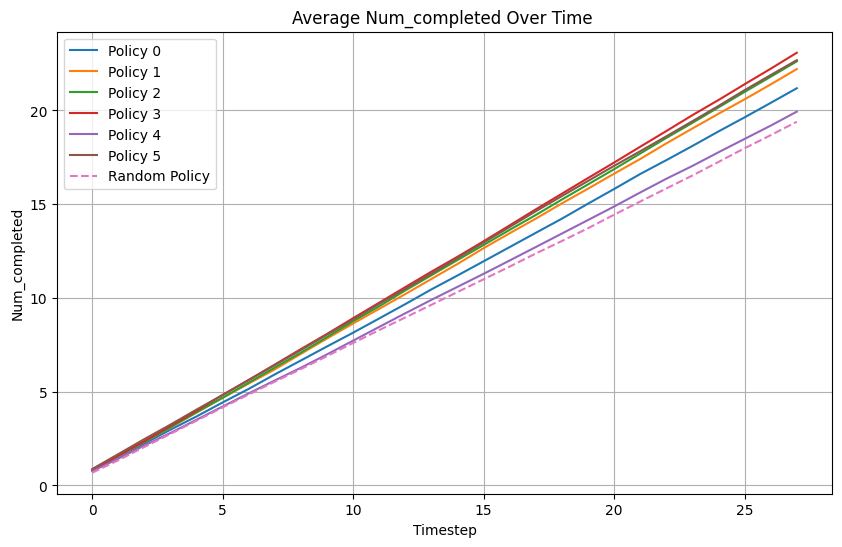

In [37]:
sim_utils.plot_simulation_results(all_policies, policy_names, 'num_completed', NUM_USERS, NUM_TIMESTEPS)

#### Inspect number of users per state

In [38]:
features = ["Tiredness", "Time available", "Perceived usefulness"]
for idx, sim_res in enumerate(all_policies):
    states = np.stack(sim_res['state']).reshape(NUM_USERS, NUM_TIMESTEPS, -1)[:, -1, 0:3]
    for i in range(NUM_FEATURES):
        feature_values = states[:, i]
        count_per_value = np.bincount(feature_values.astype(int))
        print(f"Policy {policy_names[idx]} - Feature {features[i]}: Value distribution: {count_per_value}")

Policy Policy 0 - Feature Tiredness: Value distribution: [180 288  32]
Policy Policy 0 - Feature Time available: Value distribution: [155 315  30]
Policy Policy 0 - Feature Perceived usefulness: Value distribution: [ 14  17 469]
Policy Policy 1 - Feature Tiredness: Value distribution: [165 295  40]
Policy Policy 1 - Feature Time available: Value distribution: [159 314  27]
Policy Policy 1 - Feature Perceived usefulness: Value distribution: [ 11  12 477]
Policy Policy 2 - Feature Tiredness: Value distribution: [147 303  50]
Policy Policy 2 - Feature Time available: Value distribution: [139 341  20]
Policy Policy 2 - Feature Perceived usefulness: Value distribution: [ 10   9 481]
Policy Policy 3 - Feature Tiredness: Value distribution: [144 327  29]
Policy Policy 3 - Feature Time available: Value distribution: [174 294  32]
Policy Policy 3 - Feature Perceived usefulness: Value distribution: [  5   5 490]
Policy Policy 4 - Feature Tiredness: Value distribution: [161 309  30]
Policy Policy

#### Inspect diversity

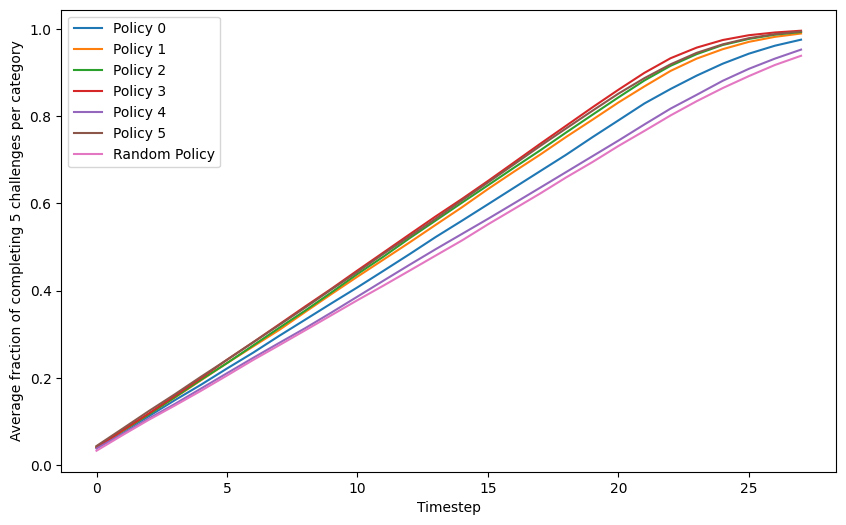

In [67]:
plt.figure(figsize=(10, 6))
for idx, sim_res in enumerate(all_policies):
    counts_per_category = np.stack(sim_res['counts_per_category']).reshape(NUM_USERS, NUM_TIMESTEPS, -1)
    max_count_per_category = 5
    counts_per_category = np.clip(counts_per_category, 0, max_count_per_category)
    counts = counts_per_category.sum(axis=2)
    fraction_completed = counts / (max_count_per_category*4)
    mean_fraction_completed = fraction_completed.mean(axis=0)
    plt.plot(mean_fraction_completed, label=policy_names[idx])
plt.xlabel('Timestep')
plt.ylabel(f'Average fraction of completing {max_count_per_category} challenges per category')
plt.legend()
